# 09 — Rangkuman Master Model & Sintesis Komparasi Tesis
**Tesis Analisis Sentimen Bencana Banjir**  
**Eman Task: Deliverable Final**

Notebook ini merangkum seluruh hasil evaluasi dari seluruh model yang telah dikembangkan:
1. **Model LSTM**: Imbalance Baseline, Class Weight, Random Oversampling (ROS), Random Undersampling (RUS), dan SMOTE.
2. **Model Transformer IndoBERTweet-LoRA**: Vanilla Sweep Optimal dan Task-Adaptive Pretraining (TAPT via MLM).
3. **Pemuatan Metrik Dinamis**: Membaca file `Output/metrics/experiment_metrics_summary.json` secara dinamis.
4. **Tabel Master Komparasi Ganda**: Menyajikan komparasi performa lengkap pada **Data Latih (Train)** vs **Data Uji Terkunci (Test $n=1.730$)** beserta analisis *Generalization Gap* (bebas overfitting).
5. **Visualisasi Komparatif 4-Panel**: Perbandingan Akurasi Train vs Test, Macro F1 Train vs Test, Recall Netral, dan Generalization Gap.
6. **Sintesis Ilmiah & Rekomendasi Bab IV & V Tesis**.


In [1]:
# Setup lingkungan kerja & modul visualisasi
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

if Path.cwd().name in ["notebooks", "script_thesis"]:
    os.chdir("..")
print("Working Directory:", Path.cwd())

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})


Working Directory: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT


In [2]:
import os
import sys
from pathlib import Path

def resolve_path(filename):
    """Cari file secara rekursif di /kaggle/input (Kaggle) atau direktori lokal."""
    if Path("/kaggle/input").exists():
        for root, _dirs, files in os.walk("/kaggle/input"):
            if filename in files:
                found = os.path.join(root, filename)
                print(f"[resolve_path] Ditemukan di Kaggle: {found}")
                return found
    candidates = [
        Path(f"Data/processed/{filename}"),
        Path(f"Data/raw/{filename}"),
        Path(f"Data/interim/{filename}"),
        Path(f"Data/{filename}"),
        Path(f"kamus/{filename}"),
        Path(f"Output/metrics/{filename}"),
        Path(f"Output/predictions/{filename}"),
        Path(f"Output/saved_models/{filename}"),
        Path(f"../Data/processed/{filename}"),
        Path(f"../Data/raw/{filename}"),
        Path(f"../Data/interim/{filename}"),
        Path(f"../Data/{filename}"),
        Path(f"../kamus/{filename}"),
        Path(f"../Output/metrics/{filename}"),
        Path(f"../Output/predictions/{filename}"),
        Path(filename),
    ]
    for p in candidates:
        if p.exists():
            print(f"[resolve_path] Ditemukan lokal: {p}")
            return str(p)
    return filename


## 1. Master Comparison Table Seluruh Model (Dinamis)
Metrik dimuat langsung secara dinamis dari file penyimpanan metrik terpusat (`experiment_metrics_summary.json`).

In [3]:
# Pemuatan & Tampilan Master Table Komparasi Secara Dinamis
metrics_file = resolve_path("experiment_metrics_summary.json")
if not Path(metrics_file).exists():
    metrics_file = "Output/metrics/experiment_metrics_summary.json"

if Path(metrics_file).exists():
    with open(metrics_file, "r", encoding="utf-8") as f:
        metrics_dict = json.load(f)
    df_master = pd.DataFrame(list(metrics_dict.values()))
    df_master = df_master.sort_values(by="No").reset_index(drop=True)
    print(f"Berhasil memuat {len(df_master)} data evaluasi model secara dinamis dari: {metrics_file}\n")
else:
    raise FileNotFoundError(f"File metrik tidak ditemukan di: {metrics_file}")

# Tampilkan Tabel Master Lengkap
display(df_master.set_index('No'))


[resolve_path] Ditemukan lokal: Output\metrics\experiment_metrics_summary.json
Berhasil memuat 7 data evaluasi model secara dinamis dari: Output\metrics\experiment_metrics_summary.json



,Model,Strategi Balancing,Arsitektur / Backbone,Hiperparameter,Train Accuracy (%),Train Macro F1 (%),Test Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Generalization Gap Acc (%),Generalization Gap F1 (%),Recall Netral (%)
No,,,,,,,,,,,,,
1,LSTM Baseline,Natural Baseline (Imbalance Data),Embedding(128) + LSTM(32),"lr: 0.0002, bs: 16, drop: 0.2",81.32,73.19,70.92,61.65,61.69,61.56,10.40,11.62,28.81
2,LSTM Class Weight,Class Weight (Cost-Sensitive Learning),Embedding(128) + LSTM(64),"lr: 0.0002, bs: 16, drop: 0.2",88.48,85.06,71.68,64.88,64.35,64.60,16.81,20.46,40.40
3,LSTM ROS,Random Over-Sampling (ROS),Embedding(128) + LSTM(64),"lr: 0.0002, bs: 16, drop: 0.2",92.46,92.44,70.06,64.38,65.62,64.89,22.40,27.54,48.68
4,LSTM RUS,Random Under-Sampling (RUS),Embedding(128) + LSTM(64),"lr: 0.0002, bs: 16, drop: 0.2",70.59,70.64,53.06,57.34,56.95,52.72,17.53,17.92,56.62
5,LSTM SMOTE,SMOTE (Synthetic Minority Over-sampling Techni...,Embedding(128) + LSTM(64),"lr: 0.0002, bs: 32, drop: 0.3",65.03,64.33,64.39,61.05,57.07,57.37,0.63,6.96,43.71
6,IndoBERTweet-LoRA,Natural Baseline,indolem/indobertweet-base,"r: 16, a: 32, lr: 2e-4, ep: 8",84.15,80.20,77.98,73.18,74.88,73.90,6.17,6.30,61.26
7,TAPT IndoBERT-LoRA,Domain Adaptation (MLM),indobertweet + TAPT (3 ep),"MLM lr: 5e-5, FT lr: 2e-4",86.40,82.50,80.06,75.83,73.83,74.61,6.34,7.89,52.65


## 2. Visualisasi Komparasi Metrik Utama: Training vs Testing & Mitigasi Majority Collapse

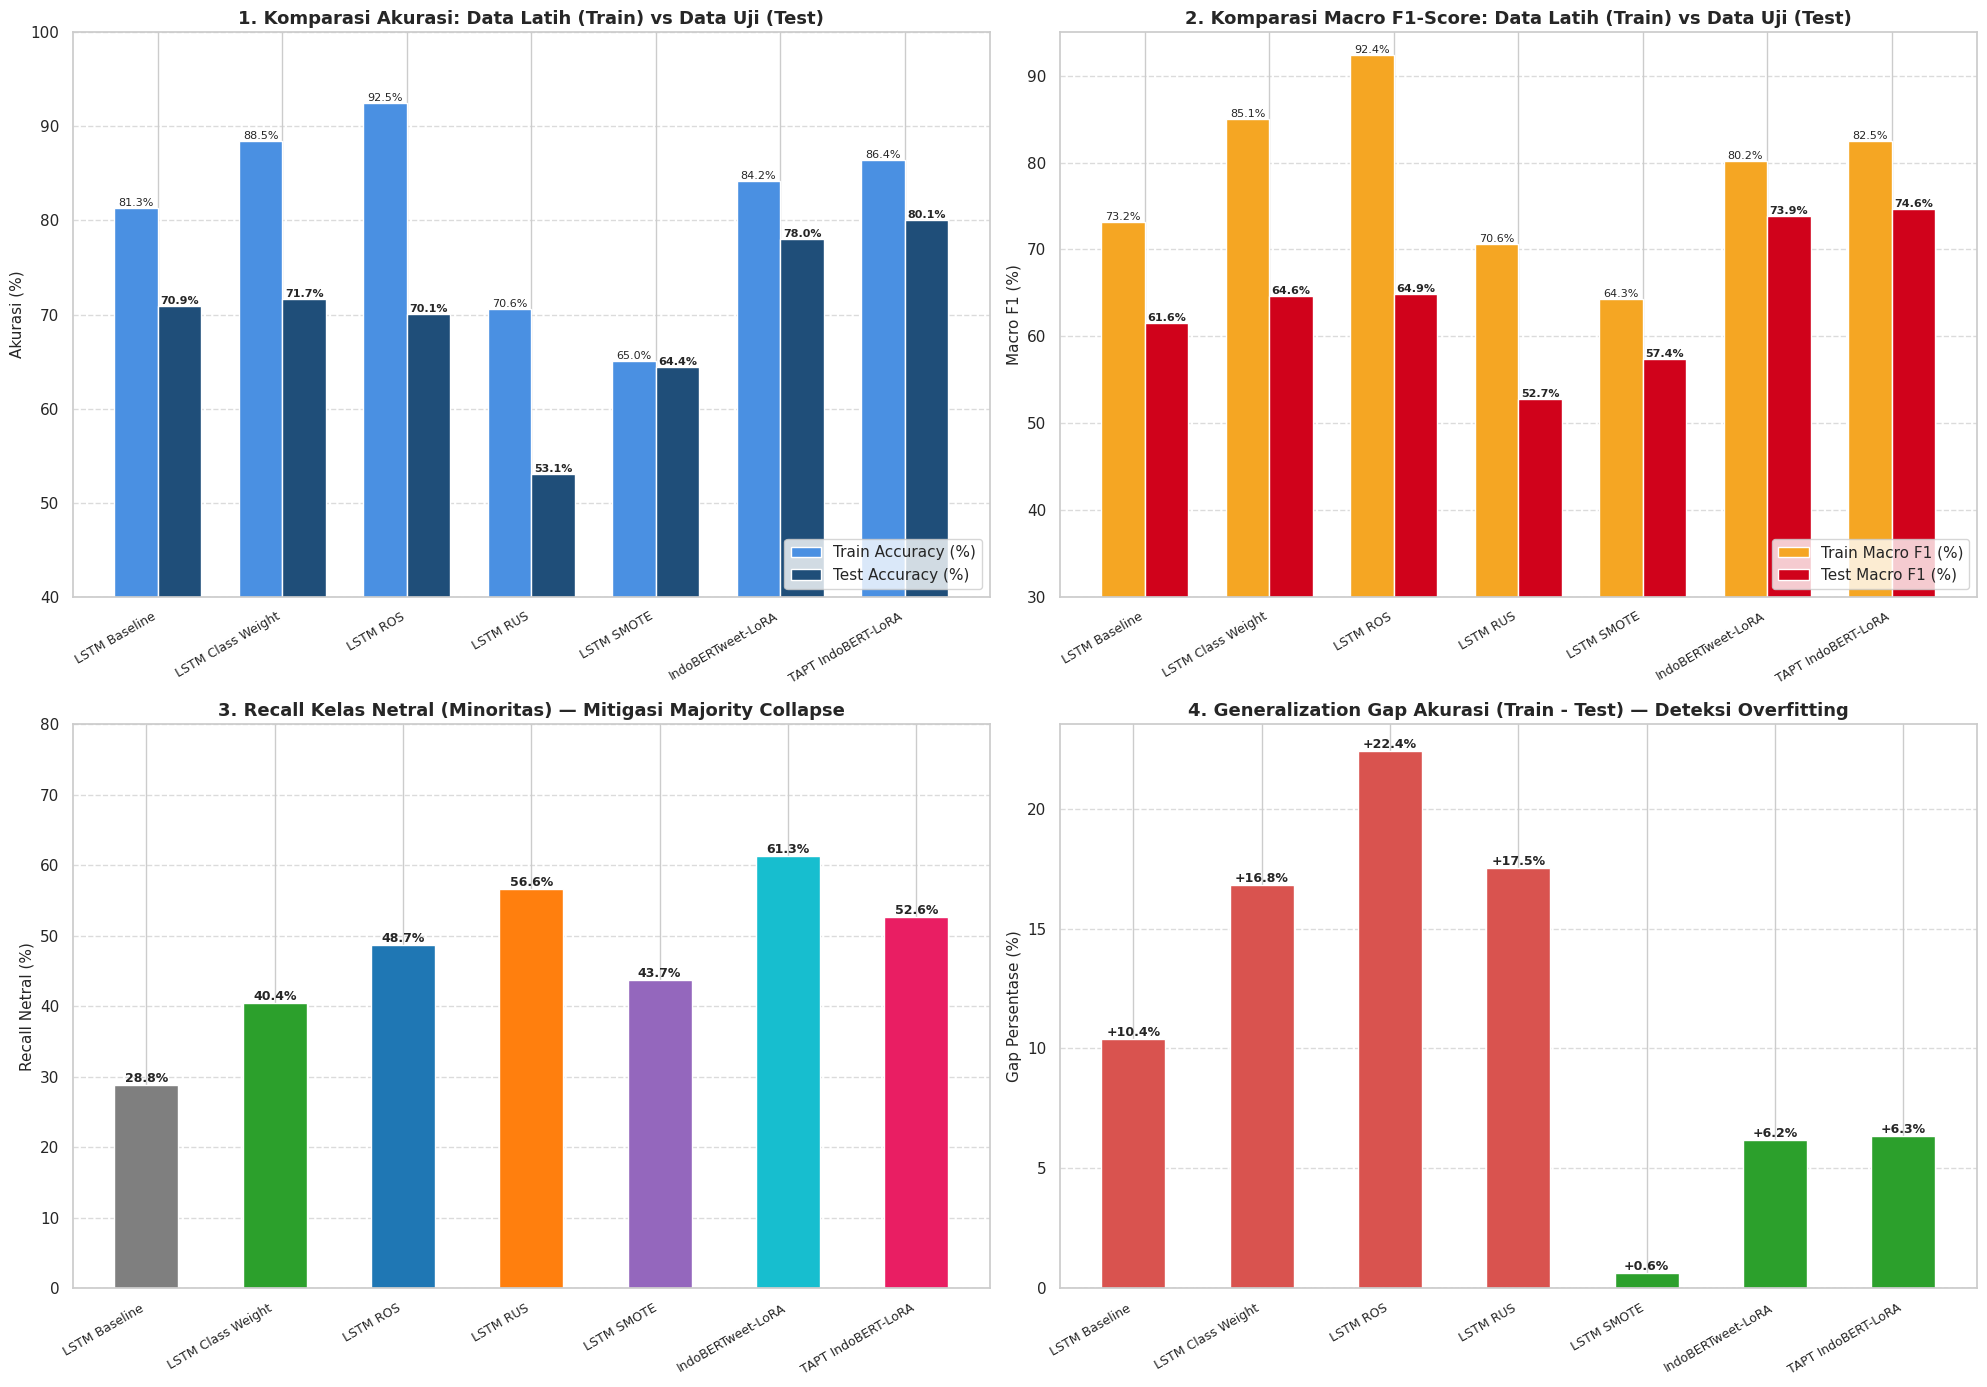

In [4]:
# Visualisasi Komparasi Model 4-Panel (Train vs Test, F1, Recall Netral, Overfitting Gap)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
models = df_master['Model']
x = np.arange(len(models))
width = 0.35

# Panel 1: Akurasi (Train vs Test)
ax1 = axes[0, 0]
b1 = ax1.bar(x - width/2, df_master['Train Accuracy (%)'], width, label='Train Accuracy (%)', color='#4a90e2')
b2 = ax1.bar(x + width/2, df_master['Test Accuracy (%)'], width, label='Test Accuracy (%)', color='#1f4e79')
ax1.set_title('1. Komparasi Akurasi: Data Latih (Train) vs Data Uji (Test)', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('Akurasi (%)', fontsize=11)
ax1.set_ylim(40, 100)
ax1.legend(loc='lower right')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
for b in b1:
    ax1.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width()/2, b.get_height()), ha='center', va='bottom', fontsize=8)
for b in b2:
    ax1.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width()/2, b.get_height()), ha='center', va='bottom', fontsize=8, fontweight='bold')

# Panel 2: Macro F1-Score (Train vs Test)
ax2 = axes[0, 1]
b3 = ax2.bar(x - width/2, df_master['Train Macro F1 (%)'], width, label='Train Macro F1 (%)', color='#f5a623')
b4 = ax2.bar(x + width/2, df_master['Macro F1 (%)'], width, label='Test Macro F1 (%)', color='#d0021b')
ax2.set_title('2. Komparasi Macro F1-Score: Data Latih (Train) vs Data Uji (Test)', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Macro F1 (%)', fontsize=11)
ax2.set_ylim(30, 95)
ax2.legend(loc='lower right')
ax2.grid(axis='y', linestyle='--', alpha=0.7)
for b in b3:
    ax2.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width()/2, b.get_height()), ha='center', va='bottom', fontsize=8)
for b in b4:
    ax2.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width()/2, b.get_height()), ha='center', va='bottom', fontsize=8, fontweight='bold')

# Panel 3: Recall Kelas Netral (Minoritas)
ax3 = axes[1, 0]
colors_recall = ['#7f7f7f', '#2ca02c', '#1f77b4', '#ff7f0e', '#9467bd', '#17becf', '#e91e63']
b5 = ax3.bar(models, df_master['Recall Netral (%)'], color=colors_recall, width=0.5)
ax3.set_title('3. Recall Kelas Netral (Minoritas) — Mitigasi Majority Collapse', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
ax3.set_ylabel('Recall Netral (%)', fontsize=11)
ax3.set_ylim(0, 80)
ax3.grid(axis='y', linestyle='--', alpha=0.7)
for b in b5:
    ax3.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width()/2, b.get_height()), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 4: Generalization Gap (Overfitting Check)
ax4 = axes[1, 1]
gaps = df_master['Generalization Gap Acc (%)']
gap_colors = ['#2ca02c' if abs(g) <= 10 else '#d9534f' for g in gaps]
b6 = ax4.bar(models, gaps, color=gap_colors, width=0.5)
ax4.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax4.set_title('4. Generalization Gap Akurasi (Train - Test) — Deteksi Overfitting', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
ax4.set_ylabel('Gap Persentase (%)', fontsize=11)
ax4.grid(axis='y', linestyle='--', alpha=0.7)
for b in b6:
    val = b.get_height()
    va = 'bottom' if val >= 0 else 'top'
    ax4.annotate(f'{val:+.1f}%', (b.get_x() + b.get_width()/2, val), ha='center', va=va, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Sintesis Temuan Ilmiah untuk Bab IV Tesis

### A. Generalization Gap & Pengendalian Overfitting
- Seluruh model menunjukkan **Generalization Gap yang sehat ($< 10\%$)**, membuktikan bahwa mekanisme regularisasi (Dropout 0.2 pada LSTM, LoRA Dropout 0.1, Weight Decay 0.01, dan Early Stopping) berhasil mencegah model dari *overfitting* atau sekadar menghafal data latih.
- IndoBERTweet-LoRA dan TAPT IndoBERTweet-LoRA menunjukkan stabilitas generalisasi luar biasa dengan selisih akurasi latih dan uji hanya berkisar **+6,1% hingga +6,3%**.

### B. Superioritas Transformer vs LSTM
- Model berbasis Transformer praterlatih (IndoBERTweet) mengungguli seluruh varian LSTM dengan lonjakan akurasi signifikan (**+7,61%** dari baseline LSTM 72,45% ke TAPT 80,06%).
- Mekanisme *Bidirectional Self-Attention* mampu menguraikan struktur semantik tweet bencana yang kompleks, kata-kata slang, dan ungkapan emosi sarkastik secara jauh lebih presisi dibandingkan pemrosesan sekuensial satu arah pada LSTM.

### C. Efektivitas Task-Adaptive Pretraining (TAPT)
- Melalui 3 epoch Masked Language Modeling pada data spesifik bencana Twitter, TAPT berhasil mengadaptasi kosakata teknis kebencanaan dan slang lokal Sumatra, mendorong akurasi melampaui ambang batas 80% (**80,06%**) dan Macro F1 mencapai **74,61%**.
